In [1]:
import os
import subprocess
import chemiscope
import ipi
import matplotlib.pyplot as plt
import numpy as np
from ase.io import read
import nqetools as nqe
from ase.visualize import view
# This follows:
# https://atomistic-cookbook.org/examples/pi-metad/pi-metad.html

In [2]:
# Make a directory to store everything
directory_md = "md"
directory_metamd = "metamd"
directory_metapimd = "metapimd"
n_beads = 8
timestep = 1.0
total_steps = 5000
stride = 10
temperature = 298

In [3]:
atoms = read("h5o2+.xyz", index=-1)
atoms.center(vacuum=20.0)

In [ ]:
view(atoms)

In [4]:
# Run unbiased MD
# Make sure the directory is empty
nqe.remove_directory(directory_md)
# Run the calculation
nqe.run_md(directory_md, atoms,
           driver='zundel',
           md_type="NVT-GLE",
           # xml_in="input-md.xml",
           n_beads=1,
           timestep=timestep,
           total_steps=total_steps,
           stride=stride,
           temperature=temperature,
           )

The directory md does not exist.
Running the MD (NVT-GLE) with the driver: /home/louie/anaconda3/envs/ipi_env2/lib/python3.12/site-packages/ipi/bin/i-pi-driver -u -a zundel -m zundel

 ____       ____       ____       ____
/    \     /    \     /    \     /    \
|  #################################  |
\__#_/     \____/     \____/     \_#__/
   #    _        _______  _____    #
   #   (_)      |_   __ \|_   _|   #      -*-   v 3.1  -*-
   #   __  ______ | |__) | | |     #
   Y  [  ||______||  ___/  | |     #      A Universal Force Engine
  0 0  | |       _| |_    _| |_    #
   #  [___]     |_____|  |_____|   #
 __#_       ____       ____       _#__
/  # \     /    \     /    \     / #  \
|  #################################  |
\____/     \____/     \____/     \____/

    
 @system: Initializing system object 
 @simulation: Initializing simulation object 
@ RANDOM SEED: The seed used in this calculation was 31415
 @init_file: Initializing from file init.xyz. Dimension: length, units: ang

[Atoms(symbols='O2H5', pbc=True, cell=[[43.488000125162245, 0.0, 0.0], [2.534919669540817e-15, 41.398379864393995, 0.0], [2.554980865602333e-15, 2.554980865602333e-15, 41.72600405898599]]),
 Atoms(symbols='O2H5', pbc=True, cell=[[43.488000125162245, 0.0, 0.0], [2.534919669540817e-15, 41.398379864393995, 0.0], [2.554980865602333e-15, 2.554980865602333e-15, 41.72600405898599]]),
 Atoms(symbols='O2H5', pbc=True, cell=[[43.488000125162245, 0.0, 0.0], [2.534919669540817e-15, 41.398379864393995, 0.0], [2.554980865602333e-15, 2.554980865602333e-15, 41.72600405898599]]),
 Atoms(symbols='O2H5', pbc=True, cell=[[43.488000125162245, 0.0, 0.0], [2.534919669540817e-15, 41.398379864393995, 0.0], [2.554980865602333e-15, 2.554980865602333e-15, 41.72600405898599]]),
 Atoms(symbols='O2H5', pbc=True, cell=[[43.488000125162245, 0.0, 0.0], [2.534919669540817e-15, 41.398379864393995, 0.0], [2.554980865602333e-15, 2.554980865602333e-15, 41.72600405898599]]),
 Atoms(symbols='O2H5', pbc=True, cell=[[43.4880001

In [5]:
# Run metadynamics
# Make sure the directory is empty
nqe.remove_directory(directory_metamd)
# Run the calculation
atoms = nqe.run_plumed_md(directory_metamd, atoms,
                          driver='zundel',
                          md_type="NVT-GLE",
                          n_beads=1,
                          thermostat='smart_sampling_1ps_n6_w2',
                          timestep=timestep,
                          total_steps=total_steps,
                          stride=stride,
                          temperature=temperature,
                          plumed_type="mtd-coord",
                          )

The directory data does not exist.
Running plumed MD (NVT-GLE) with the driver: /home/louie/anaconda3/envs/ipi_env2/lib/python3.12/site-packages/ipi/bin/i-pi-driver -u -a zundel -m zundel


+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/home/louie/plumed-2.9.3/src/lib/libplumedKernel.so" +++


PLUMED: PLUMED is starting
PLUMED: Version: 2.9.3 (git: Unknown) compiled on Jan 23 2025 at 11:26:41
PLUMED: Please cite these papers when using PLUMED [1][2]
PLUMED: For further information see the PLUMED web page at http://www.plumed.org
PLUMED: Root: /home/louie/plumed-2.9.3/
PLUMED: For installed feature, see /home/louie/plumed-2.9.3//src/config/config.txt
PLUMED: Molecular dynamics engine: i-pi
PLUMED: Precision of reals: 8
PLUMED: Running over 1 node
PLUMED: Number of threads: 1
PLUMED: Cache line size: 512
PLUMED: Number of atoms: 7
PLUMED: File suffix: 
PLUMED: FILE: plumed.dat
PLUMED: Action DISTANCE
PLUMED:   with label d
PLUMED:   between atoms 1 2
PLUMED:   using periodic boundary conditions
PLUMED: Action DISTANCES
PLUMED:   with label c1
PLUMED:   keyword GROUPA takes atoms : 1 
PLUMED:   keyword GROUPB takes atoms : 3 4 5 6 7 
PLUMED:   added component to this action:  c1.lessthan 
PLUMED:   value c1.lessthan is obtained by taking the 1th component and finding the number

In [6]:
output_data, output_desc = ipi.read_output(os.path.join(directory_metamd, "md.out"))
colvar_data = ipi.read_trajectory(os.path.join(directory_metamd, "md.colvar_0"), format="extras")[
    "d,c1.lessthan,c2.lessthan,dc,mtd.bias"
]
traj_data = ipi.read_trajectory(os.path.join(directory_metamd, "md.pos_0.xyz"))

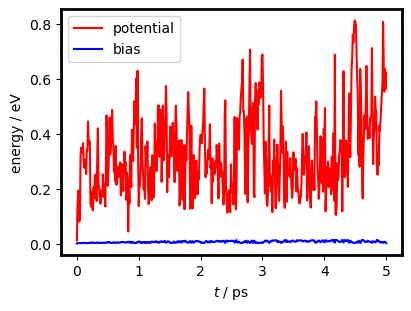

In [7]:
nqe.plot_time_potential_bias(output_data)

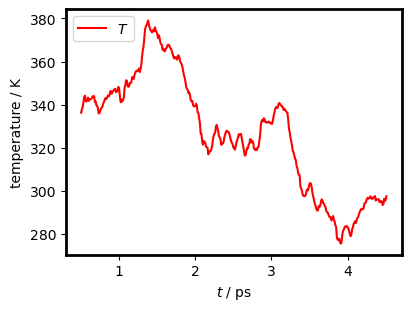

In [8]:
nqe.plot_time_temperature(output_data)

In [10]:

sum_hills_str = "plumed sum_hills --hills HILLS --min 0.21,-1 --max 0.31,1 --bin 100,100 --outfile FES --stride 100 --mintozero"

with open(os.path.join(directory_metamd, "plumed.dat"), "r") as file:
    subprocess.run(sum_hills_str.split(), stdin=file, text=True,
                   )



terminate called after throwing an instance of 'PLMD::Plumed::ExceptionError'
  what():  
(cltools/SumHills.cpp:292) virtual int PLMD::cltools::CLToolSumHills::main(FILE*, FILE*, PLMD::Communicator&)
not enough values for --min
